<a href="https://colab.research.google.com/github/Dillybabu03/Brand-Reputation-Analysis-Indian-Brands/blob/main/03_ETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Import analytics and visualization libraries
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plot style for our charts
sns.set_theme(style="whitegrid")

print("Notebook 3 successfully initialized and ready for visualizations!")


Mounted at /content/drive
Notebook 3 successfully initialized and ready for visualizations!


In [4]:
import pandas as pd
import os

PROCESSED_DATA_PATH = '/content/drive/MyDrive/SMRI_project/data/processed'
BRANDS = ["zomato", "ola_electric", "hdfc_bank", "mamaearth", "byjus"]

brand_trends = {}

print("Extracting dates and aggregating sentiment data...")

for brand in BRANDS:
    file_path = os.path.join(PROCESSED_DATA_PATH, f"{brand}_processed_sentiment.csv")

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)

        # Detect column name
        time_col = 'timestamp' if 'timestamp' in df.columns else 'date'

        if time_col in df.columns:
            # Added format='mixed' to resolve the 3-letter month abbreviation mismatch
            df['clean_date'] = pd.to_datetime(df[time_col], format='mixed').dt.date

            # Sort chronologically
            df = df.sort_values('clean_date')

            # Group by date and calculate the mean compound sentiment score
            daily_sentiment = df.groupby('clean_date')['vader_compound'].mean().reset_index()

            brand_trends[brand] = daily_sentiment
            print(f"Loaded {brand}: Processed {len(daily_sentiment)} unique days of data.")
        else:
            print(f"Error: Neither 'timestamp' nor 'date' column found in {brand}_processed_sentiment.csv")
    else:
        print(f"Warning: Processed file for {brand} not found.")

print("Data preparation complete!")

Extracting dates and aggregating sentiment data...
Loaded zomato: Processed 49 unique days of data.
Loaded ola_electric: Processed 34 unique days of data.
Loaded hdfc_bank: Processed 31 unique days of data.
Loaded mamaearth: Processed 43 unique days of data.
Loaded byjus: Processed 23 unique days of data.
Data preparation complete!


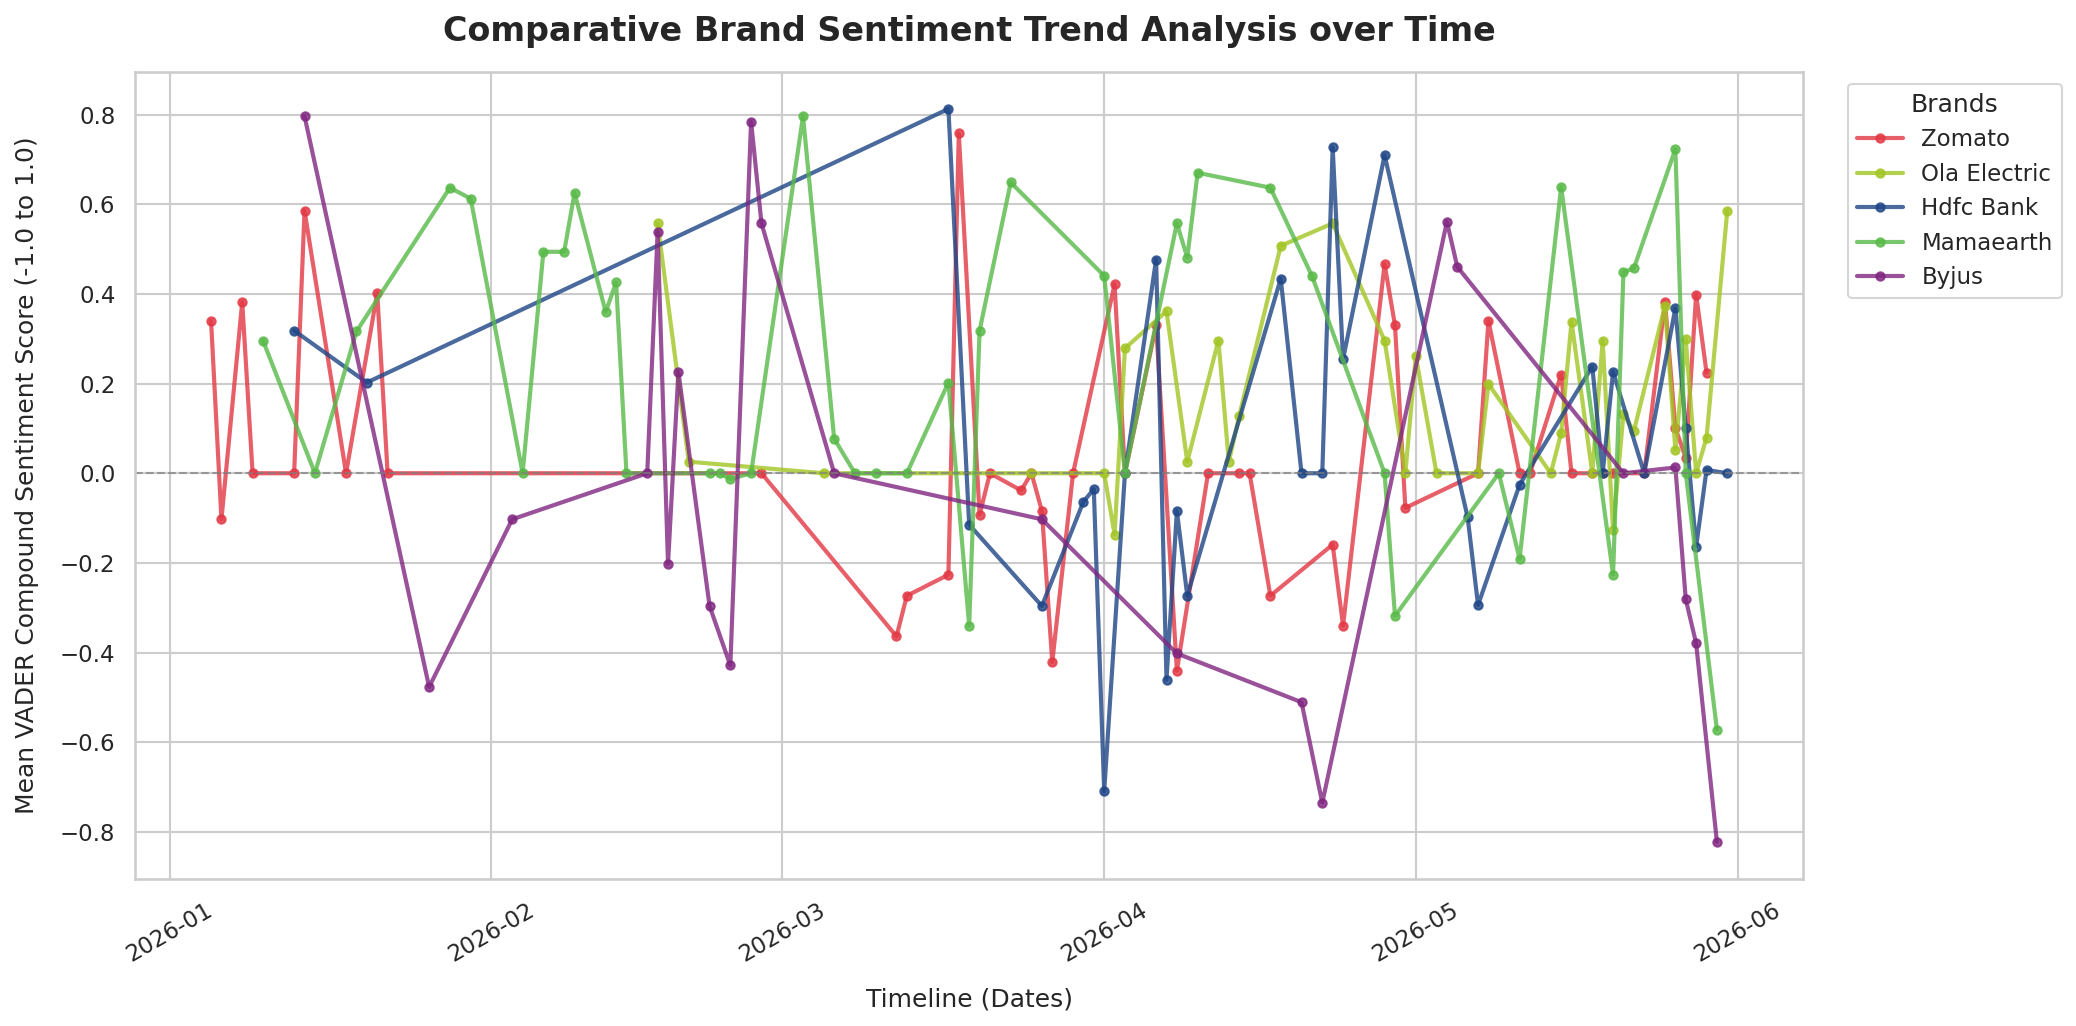

Visualization successfully rendered and saved to: /content/drive/MyDrive/SMRI_project/data/processed/brand_sentiment_trends.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure the dimensions and quality of our graph
plt.figure(figsize=(14, 7), dpi=150)

# Colors matching each specific corporate profile
brand_colors = {
    "zomato": "#E23744",       # Zomato Red
    "ola_electric": "#A2C523", # Ola Lime Green
    "hdfc_bank": "#1D4586",    # HDFC Navy Blue
    "mamaearth": "#58B947",    # Mamaearth Green
    "byjus": "#802681"         # Byju's Purple
}

# Plot the daily moving trend for each brand
for brand, data in brand_trends.items():
    # Sort data by date just in case to avoid jagged line plotting
    data = data.sort_values('clean_date')

    plt.plot(
        data['clean_date'],
        data['vader_compound'],
        label=brand.replace('_', ' ').title(),
        color=brand_colors.get(brand, '#333333'),
        linewidth=2,
        marker='o',
        markersize=4,
        alpha=0.8
    )

# Customize graph aesthetics
plt.title("Comparative Brand Sentiment Trend Analysis over Time", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Timeline (Dates)", fontsize=12, labelpad=10)
plt.ylabel("Mean VADER Compound Sentiment Score (-1.0 to 1.0)", fontsize=12, labelpad=10)

# Add a dashed horizontal line at 0.0 to mark the neutral boundary
plt.axhline(0.0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Rotate x-axis dates slightly for cleaner scannability
plt.xticks(rotation=30)
plt.legend(title="Brands", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()

# Save the visualization directly into your processed folder for reporting
output_image_path = '/content/drive/MyDrive/SMRI_project/data/processed/brand_sentiment_trends.png'
plt.savefig(output_image_path, bbox_inches='tight')

# Render the plot inside the notebook
plt.show()

print(f"Visualization successfully rendered and saved to: {output_image_path}")

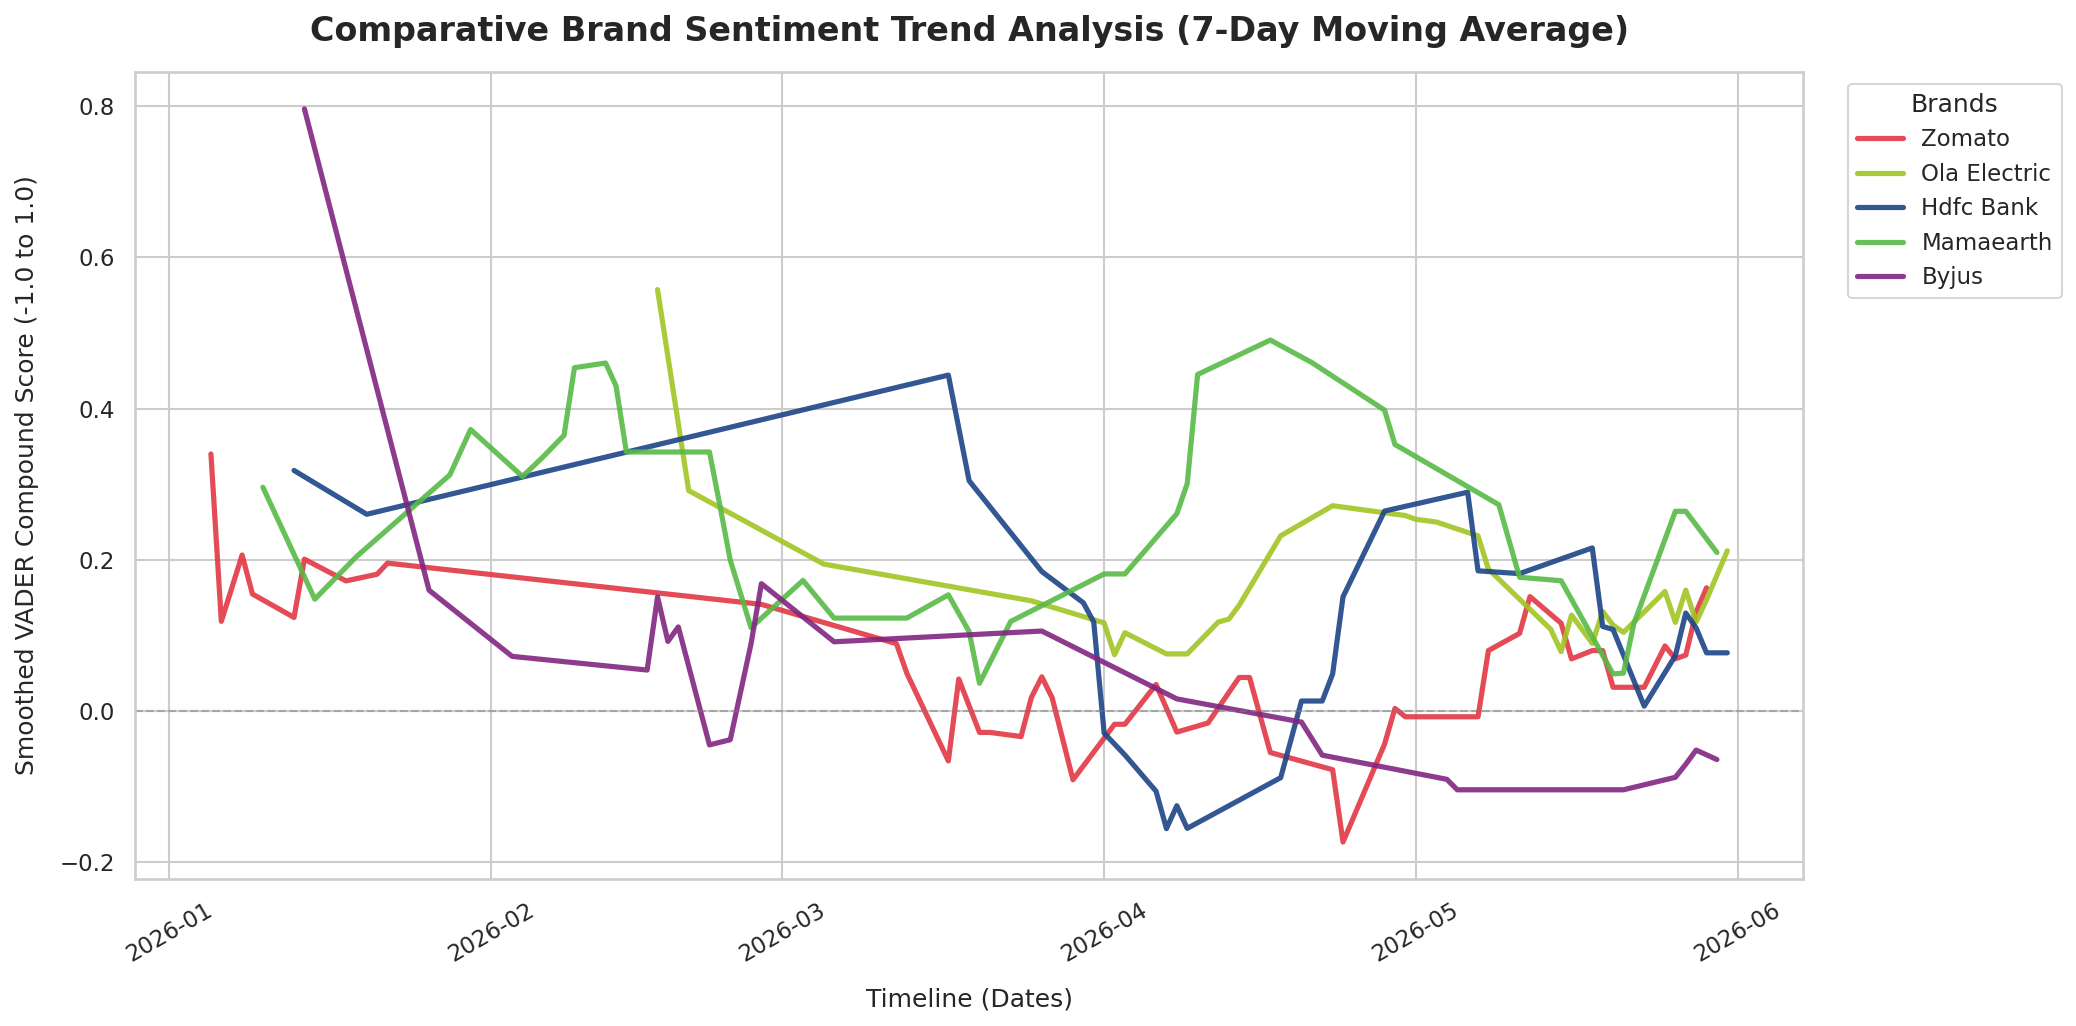

Cleaned visualization saved to: /content/drive/MyDrive/SMRI_project/data/processed/brand_sentiment_trends_smooth.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7), dpi=150)

brand_colors = {
    "zomato": "#E23744",
    "ola_electric": "#A2C523",
    "hdfc_bank": "#1D4586",
    "mamaearth": "#58B947",
    "byjus": "#802681"
}

for brand, data in brand_trends.items():
    # Make sure data is sorted by date
    data = data.sort_values('clean_date').copy()

    # Set the date as index to allow proper time-series window calculations
    data = data.set_index('clean_date')

    # Calculate a 7-day rolling moving average (min_periods=1 handles sparse dates)
    data['smoothed_sentiment'] = data['vader_compound'].rolling(window=7, min_periods=1).mean()

    # Plot the smooth trend line
    plt.plot(
        data.index,
        data['smoothed_sentiment'],
        label=brand.replace('_', ' ').title(),
        color=brand_colors.get(brand, '#333333'),
        linewidth=2.5,
        alpha=0.9
    )

plt.title("Comparative Brand Sentiment Trend Analysis (7-Day Moving Average)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Timeline (Dates)", fontsize=12, labelpad=10)
plt.ylabel("Smoothed VADER Compound Score (-1.0 to 1.0)", fontsize=12, labelpad=10)

# Reference line for neutral sentiment
plt.axhline(0.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.xticks(rotation=30)
plt.legend(title="Brands", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()

# Save the clean visualization
output_image_path = '/content/drive/MyDrive/SMRI_project/data/processed/brand_sentiment_trends_smooth.png'
plt.savefig(output_image_path, bbox_inches='tight')
plt.show()

print(f"Cleaned visualization saved to: {output_image_path}")

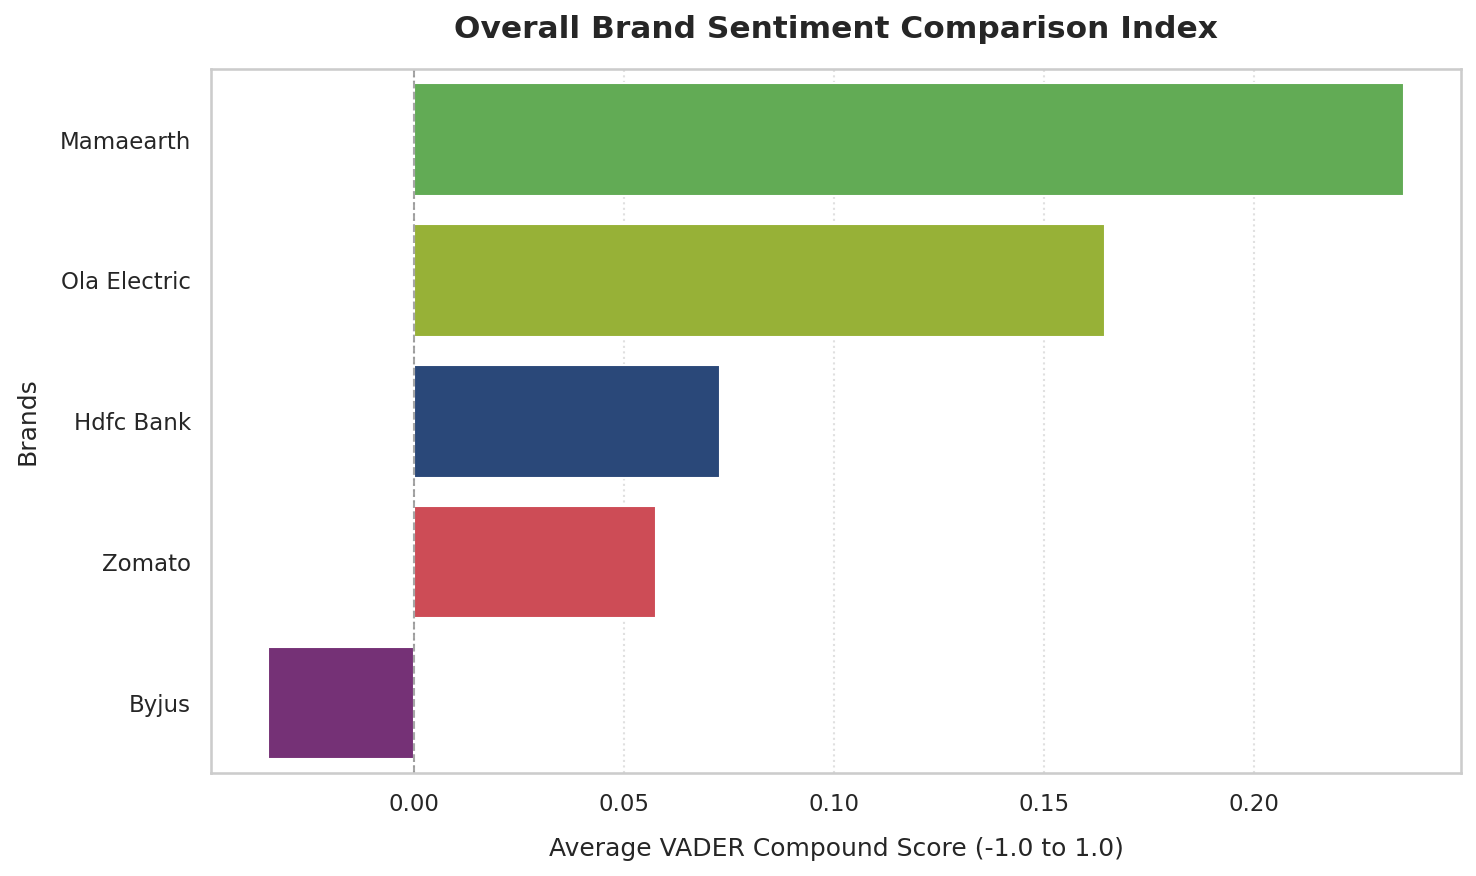

Overall comparison chart successfully saved to: /content/drive/MyDrive/SMRI_project/data/processed/overall_brand_comparison.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate global average sentiment for each brand
overall_scores = []

for brand, data in brand_trends.items():
    avg_score = data['vader_compound'].mean()
    overall_scores.append({
        'Brand': brand.replace('_', ' ').title(),
        'Overall Sentiment': avg_score
    })

# Convert to a DataFrame for easier plotting
df_overall = pd.DataFrame(overall_scores).sort_values(by='Overall Sentiment', ascending=False)

# Configure the plot dimensions
plt.figure(figsize=(10, 6), dpi=150)

# Colors matching each specific corporate profile mapped to the sorted order
brand_colors = {
    "Zomato": "#E23744",
    "Ola Electric": "#A2C523",
    "Hdfc Bank": "#1D4586",
    "Mamaearth": "#58B947",
    "Byjus": "#802681"
}
colors_list = [brand_colors.get(b, '#333333') for b in df_overall['Brand']]

# Generate bar plot
sns.barplot(
    x='Overall Sentiment',
    y='Brand',
    data=df_overall,
    palette=colors_list,
    hue='Brand',
    legend=False
)

# Customizing graph aesthetics
plt.title("Overall Brand Sentiment Comparison Index", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Average VADER Compound Score (-1.0 to 1.0)", fontsize=12, labelpad=10)
plt.ylabel("Brands", fontsize=12, labelpad=10)

# Add baseline reference for neutrality
plt.axvline(0.0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Set grid lines behind bars
plt.gca().set_axisbelow(True)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()

# Save the visualization directly into your processed folder
output_bar_path = '/content/drive/MyDrive/SMRI_project/data/processed/overall_brand_comparison.png'
plt.savefig(output_bar_path, bbox_inches='tight')
plt.show()

print(f"Overall comparison chart successfully saved to: {output_bar_path}")

Starting secondary ETL pass...
Master summary dataframe compiled successfully.


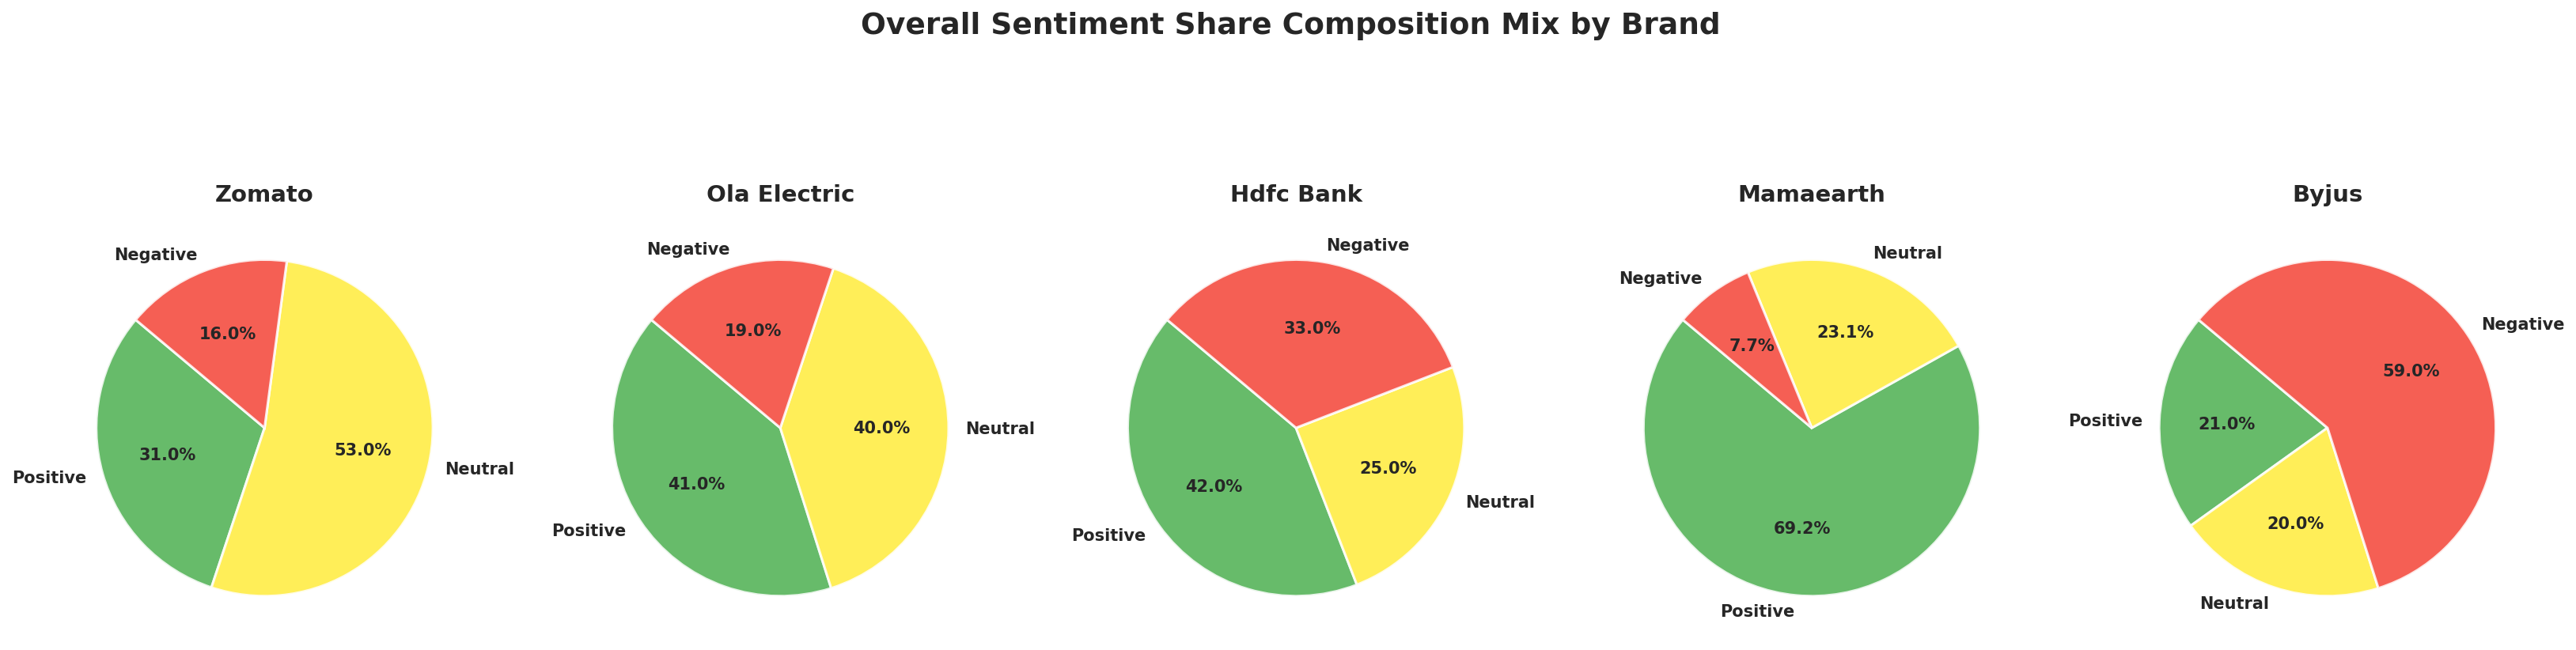

Pie chart matrix successfully exported to: /content/drive/MyDrive/SMRI_project/data/processed/brand_sentiment_pie_mix.png

Final Master Summary Metrics Table:
       Brand  Total Articles  Avg VADER Compound  Avg TextBlob Polarity  Positive Vol  Neutral Vol  Negative Vol
      Zomato             100            0.091853               0.070544            31           53            16
Ola Electric             100            0.116013               0.028234            41           40            19
   Hdfc Bank             100            0.064484               0.051855            42           25            33
   Mamaearth              91            0.327608               0.117862            63           21             7
       Byjus             100           -0.207882              -0.009832            21           20            59


In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DATA_PATH = '/content/drive/MyDrive/SMRI_project/data/processed'
BRANDS = ["zomato", "ola_electric", "hdfc_bank", "mamaearth", "byjus"]

# Data structures to store our new metrics
master_summary_data = []
brand_sentiment_mix = {}

print("Starting secondary ETL pass...")

for brand in BRANDS:
    file_path = os.path.join(PROCESSED_DATA_PATH, f"{brand}_processed_sentiment.csv")

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)

        # ETL Transformation: Define sentiment tiers based on VADER compound scores
        # Positive (> 0.05), Negative (< -0.05), Neutral (between -0.05 and 0.05)
        df['sentiment_category'] = df['vader_compound'].apply(
            lambda score: 'Positive' if score > 0.05 else ('Negative' if score < -0.05 else 'Neutral')
        )

        # Save categorical splits back to the file
        df.to_csv(file_path, index=False)

        # Calculate volume metrics
        total_articles = len(df)
        category_counts = df['sentiment_category'].value_counts()

        pos_count = category_counts.get('Positive', 0)
        neg_count = category_counts.get('Negative', 0)
        neu_count = category_counts.get('Neutral', 0)

        brand_sentiment_mix[brand] = [pos_count, neu_count, neg_count]

        # Aggregate stats for the master report
        master_summary_data.append({
            'Brand': brand.replace('_', ' ').title(),
            'Total Articles': total_articles,
            'Avg VADER Compound': df['vader_compound'].mean(),
            'Avg TextBlob Polarity': df['textblob_polarity'].mean(),
            'Positive Vol': pos_count,
            'Neutral Vol': neu_count,
            'Negative Vol': neg_count
        })

# Save the final Master Summary Table
df_master = pd.DataFrame(master_summary_data)
master_output_path = os.path.join(PROCESSED_DATA_PATH, 'master_brand_analytics_summary.csv')
df_master.to_csv(master_output_path, index=False)
print("Master summary dataframe compiled successfully.")

# --- Visualizing the Sentiment Share via Pie Charts ---

fig, axes = plt.subplots(1, 5, figsize=(22, 6), dpi=150)
pie_colors = ['#4CAF50', '#FFEB3B', '#F44336'] # Clean Green, Yellow, Red
labels = ['Positive', 'Neutral', 'Negative']

for i, brand in enumerate(BRANDS):
    if brand in brand_sentiment_mix:
        axes[i].pie(
            brand_sentiment_mix[brand],
            labels=labels,
            autopct='%1.1f%%',
            startangle=140,
            colors=pie_colors,
            textprops={'fontsize': 10, 'weight': 'bold'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'alpha': 0.85}
        )
        axes[i].set_title(brand.replace('_', ' ').title(), fontsize=14, fontweight='bold', pad=10)

plt.suptitle("Overall Sentiment Share Composition Mix by Brand", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()

pie_output_path = os.path.join(PROCESSED_DATA_PATH, 'brand_sentiment_pie_mix.png')
plt.savefig(pie_output_path, bbox_inches='tight')
plt.show()

print(f"Pie chart matrix successfully exported to: {pie_output_path}")
print("\nFinal Master Summary Metrics Table:")
print(df_master.to_string(index=False))

Compiling data features into unified layout...


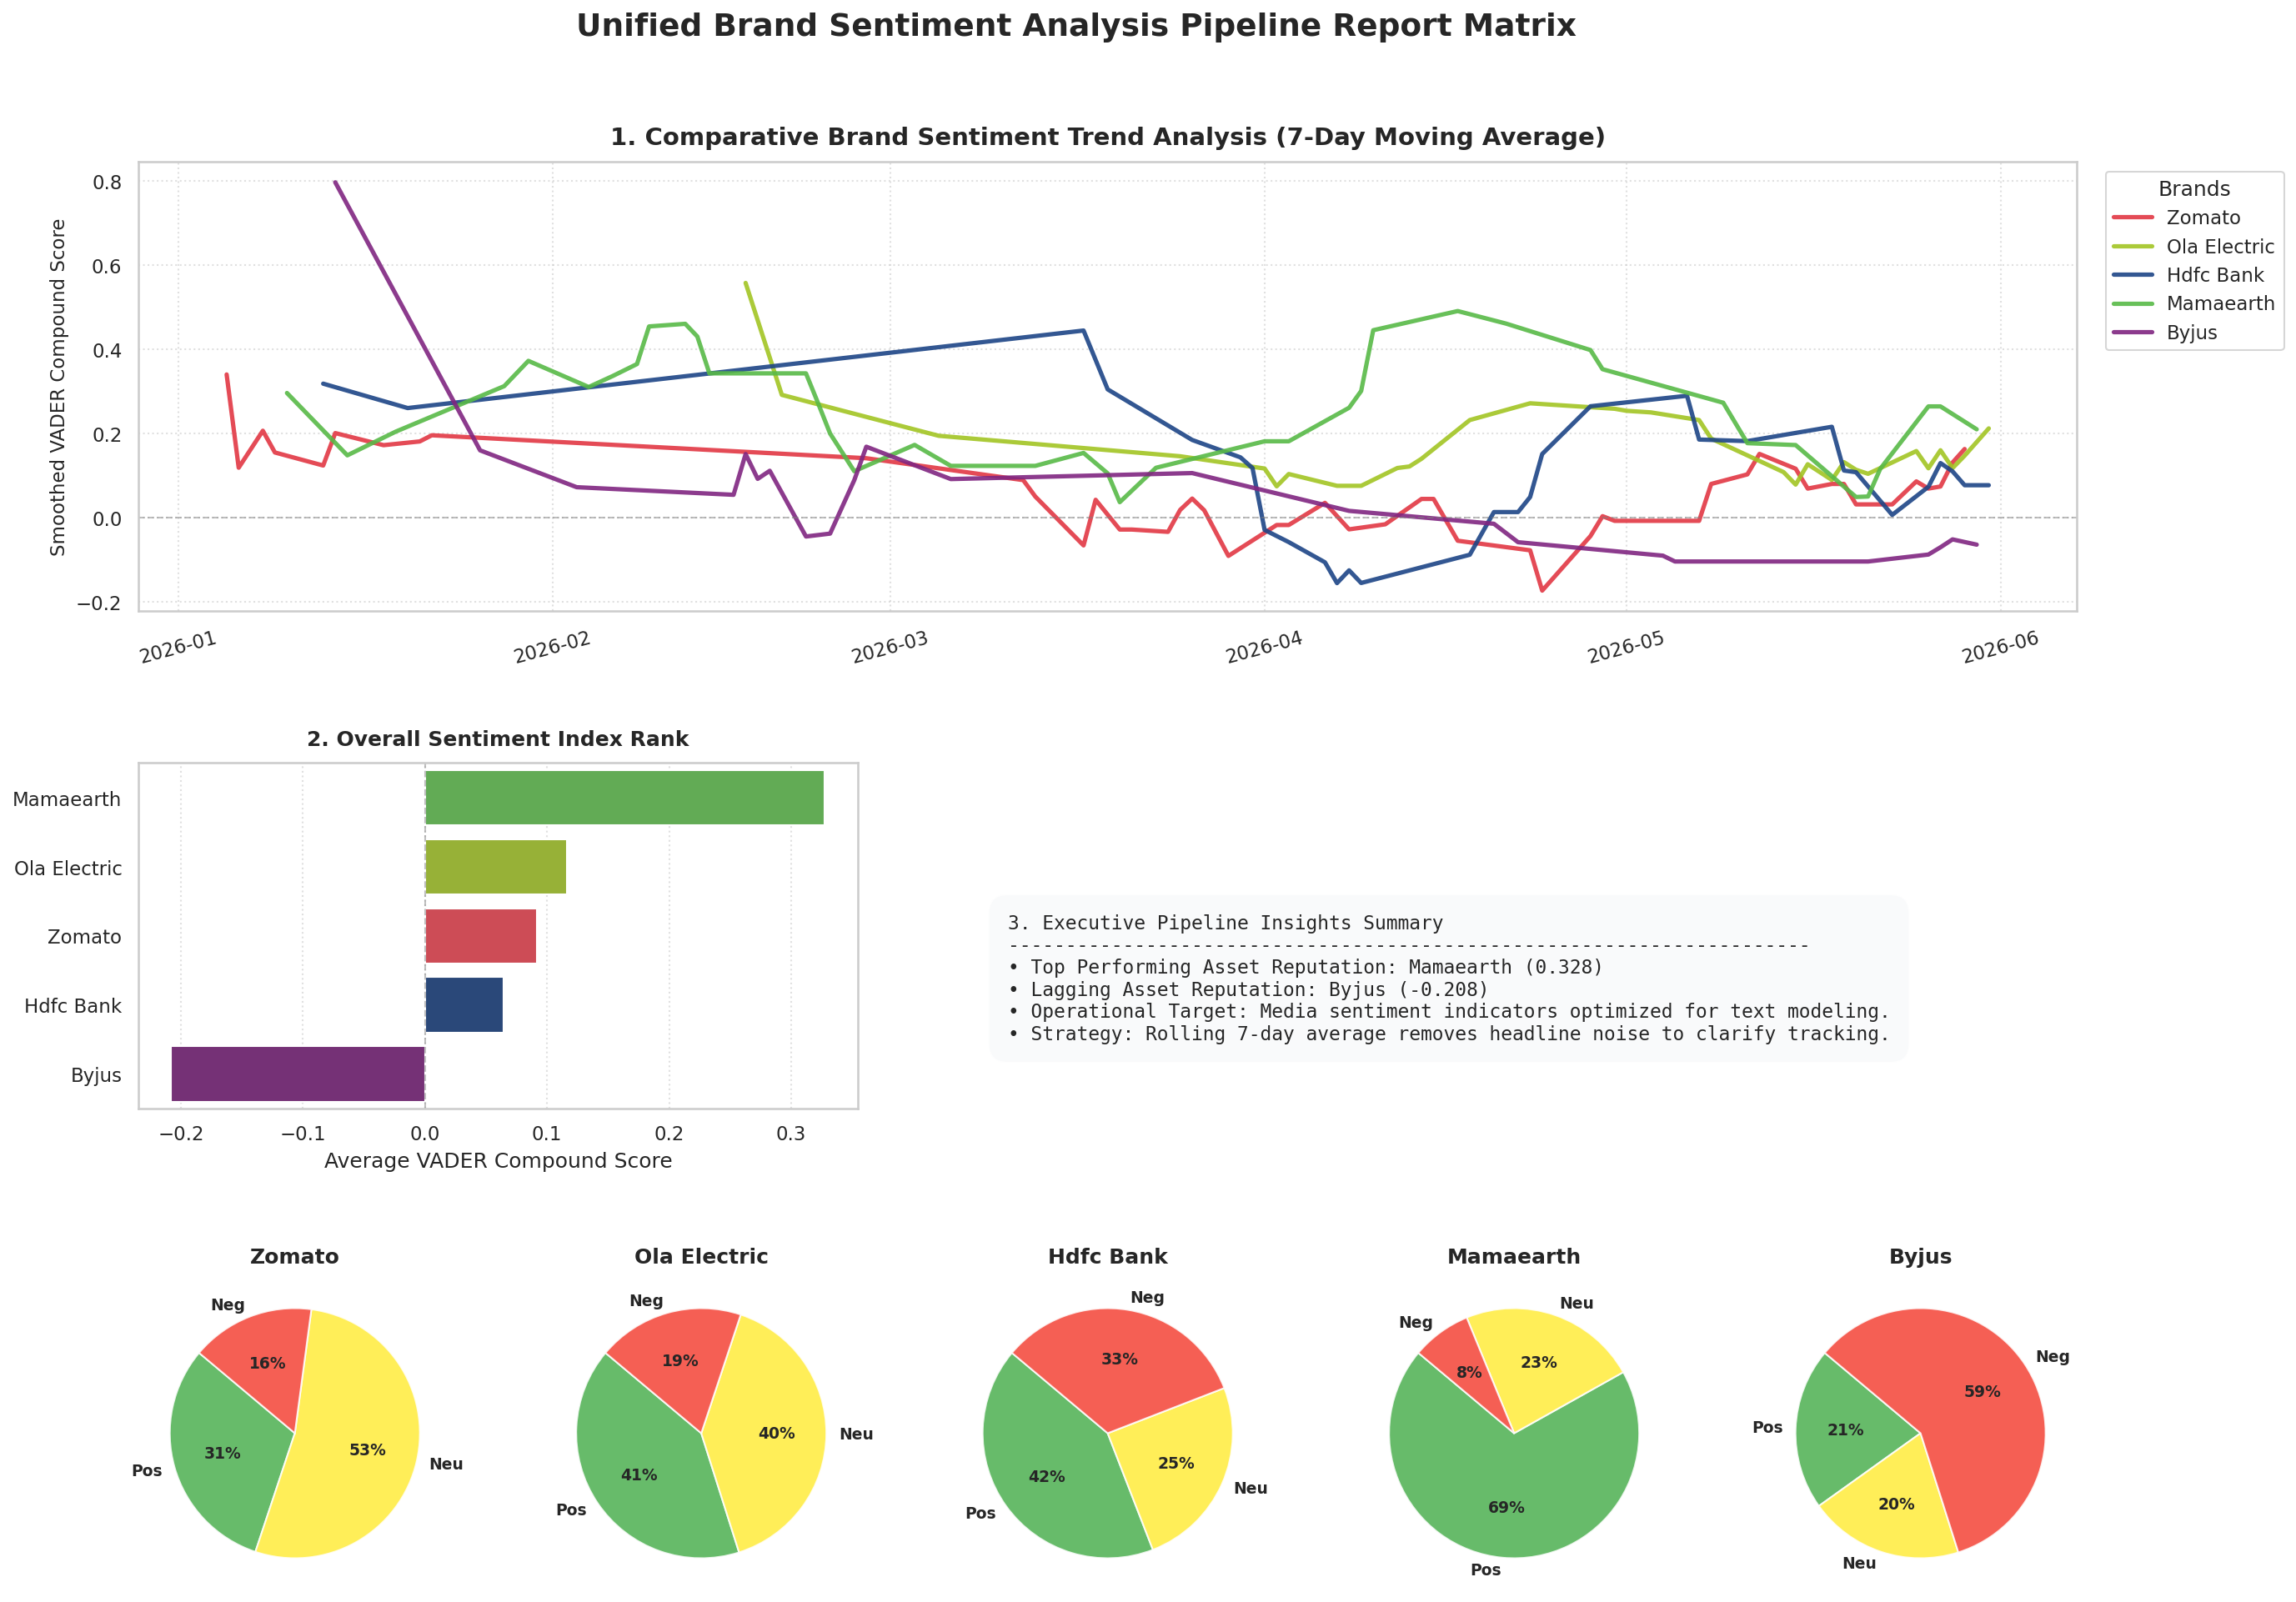

Master dashboard graphic combined and saved to: /content/drive/MyDrive/SMRI_project/data/processed/unified_brand_sentiment_dashboard.png


In [9]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DATA_PATH = '/content/drive/MyDrive/SMRI_project/data/processed'
BRANDS = ["zomato", "ola_electric", "hdfc_bank", "mamaearth", "byjus"]

brand_colors = {
    "zomato": "#E23744",       # Zomato Red
    "ola_electric": "#A2C523", # Ola Lime Green
    "hdfc_bank": "#1D4586",    # HDFC Navy Blue
    "mamaearth": "#58B947",    # Mamaearth Green
    "byjus": "#802681"         # Byju's Purple
}

pie_colors = ['#4CAF50', '#FFEB3B', '#F44336'] # Green, Yellow, Red
pie_labels = ['Pos', 'Neu', 'Neg']

# Initialize the canvas with custom sizing for a dashboard look
fig = plt.figure(figsize=(20, 15), dpi=150)
gs = fig.add_gridspec(3, 5, height_ratios=[1.3, 1, 1], hspace=0.4, wspace=0.3)

print("Compiling data features into unified layout...")

# --- 1. TOP ROW: Smoothed Time-Series Line Chart (Spans all 5 columns) ---
ax_line = fig.add_subplot(gs[0, :])

overall_scores = []
brand_sentiment_mix = {}

for brand in BRANDS:
    file_path = os.path.join(PROCESSED_DATA_PATH, f"{brand}_processed_sentiment.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)

        # Parse Dates & Sort
        time_col = 'timestamp' if 'timestamp' in df.columns else 'date'
        df['clean_date'] = pd.to_datetime(df[time_col], format='mixed').dt.date
        daily_sentiment = df.groupby('clean_date')['vader_compound'].mean().reset_index()
        daily_sentiment = daily_sentiment.sort_values('clean_date').set_index('clean_date')

        # Calculate Rolling 7-Day Average
        daily_sentiment['smoothed'] = daily_sentiment['vader_compound'].rolling(window=7, min_periods=1).mean()

        # Plot to Line Axis
        ax_line.plot(
            daily_sentiment.index,
            daily_sentiment['smoothed'],
            label=brand.replace('_', ' ').title(),
            color=brand_colors[brand],
            linewidth=2.5,
            alpha=0.9
        )

        # Gather data for downstream bar and pie matrices
        overall_scores.append({
            'Brand': brand.replace('_', ' ').title(),
            'Score': df['vader_compound'].mean()
        })

        df['category'] = df['vader_compound'].apply(lambda x: 'Pos' if x > 0.05 else ('Neg' if x < -0.05 else 'Neu'))
        counts = df['category'].value_counts()
        brand_sentiment_mix[brand] = [counts.get('Pos', 0), counts.get('Neu', 0), counts.get('Neg', 0)]

ax_line.set_title("1. Comparative Brand Sentiment Trend Analysis (7-Day Moving Average)", fontsize=14, fontweight='bold', pad=10)
ax_line.set_ylabel("Smoothed VADER Compound Score", fontsize=11)
ax_line.axhline(0.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax_line.grid(True, linestyle=':', alpha=0.6)
ax_line.legend(title="Brands", loc='upper left', bbox_to_anchor=(1.01, 1))
ax_line.tick_params(axis='x', rotation=15)


# --- 2. MIDDLE ROW: Overall Index Bar Chart (Spans first 2 columns) ---
ax_bar = fig.add_subplot(gs[1, 0:2])
df_overall = pd.DataFrame(overall_scores).sort_values(by='Score', ascending=False)
bar_colors_list = [brand_colors[b.lower().replace(' ', '_')] for b in df_overall['Brand']]

sns.barplot(
    x='Score',
    y='Brand',
    data=df_overall,
    palette=bar_colors_list,
    ax=ax_bar,
    hue='Brand',
    legend=False
)
ax_bar.set_title("2. Overall Sentiment Index Rank", fontsize=12, fontweight='bold', pad=10)
ax_bar.set_xlabel("Average VADER Compound Score")
ax_bar.set_ylabel("")
ax_bar.axvline(0.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax_bar.grid(axis='x', linestyle=':', alpha=0.6)


# --- 3. MIDDLE ROW (RIGHT): Quick Insights Text Area (Spans remaining 3 columns) ---
ax_txt = fig.add_subplot(gs[1, 2:5])
ax_txt.axis('off') # Hide axes for clean text rendering
insights_text = (
    "3. Executive Pipeline Insights Summary\n"
    "----------------------------------------------------------------------\n"
    f"• Top Performing Asset Reputation: {df_overall.iloc[0]['Brand']} ({df_overall.iloc[0]['Score']:.3f})\n"
    f"• Lagging Asset Reputation: {df_overall.iloc[-1]['Brand']} ({df_overall.iloc[-1]['Score']:.3f})\n"
    "• Operational Target: Media sentiment indicators optimized for text modeling.\n"
    "• Strategy: Rolling 7-day average removes headline noise to clarify tracking."
)
ax_txt.text(0.05, 0.2, insights_text, fontsize=11, family='monospace', bbox=dict(facecolor='#f8f9fa', alpha=0.8, boxstyle='round,pad=1'))


# --- 4. BOTTOM ROW: Sentiment Share Pie Matrix (All 5 brands across 5 columns) ---
for i, brand in enumerate(BRANDS):
    ax_pie = fig.add_subplot(gs[2, i])
    if brand in brand_sentiment_mix:
        ax_pie.pie(
            brand_sentiment_mix[brand],
            labels=pie_labels,
            autopct='%1.0f%%',
            startangle=140,
            colors=pie_colors,
            textprops={'fontsize': 9, 'weight': 'bold'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1, 'alpha': 0.85}
        )
        ax_pie.set_title(brand.replace('_', ' ').title(), fontsize=12, fontweight='bold', pad=8)

# Add master dashboard titles and save
plt.suptitle("Unified Brand Sentiment Analysis Pipeline Report Matrix", fontsize=18, fontweight='bold', y=0.96)
output_dashboard_path = '/content/drive/MyDrive/SMRI_project/data/processed/unified_brand_sentiment_dashboard.png'
plt.savefig(output_dashboard_path, bbox_inches='tight')
plt.show()

print(f"Master dashboard graphic combined and saved to: {output_dashboard_path}")

In [10]:
import pandas as pd
import os
import numpy as np

PROCESSED_DATA_PATH = '/content/drive/MyDrive/SMRI_project/data/processed'
BRANDS = ["zomato", "ola_electric", "hdfc_bank", "mamaearth", "byjus"]

expanded_summary_data = []

print("Running Expanded ETL Feature Engineering Pipeline...")

for brand in BRANDS:
    file_path = os.path.join(PROCESSED_DATA_PATH, f"{brand}_processed_sentiment.csv")

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)

        # 1. Feature Engineering: Word Counts and Character Lengths
        df['headline_length'] = df['text'].astype(str).apply(len)
        df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

        # 2. Time-Series Volatility Calculation (Standard Deviation of Compound Scores)
        sentiment_volatility = df['vader_compound'].std()

        # Save engineered features back to individual brand files
        df.to_csv(file_path, index=False)

        # 3. Categorical breakdown logic
        df['sentiment_category'] = df['vader_compound'].apply(
            lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral')
        )
        counts = df['sentiment_category'].value_counts()

        # 4. Append metrics to our summary collection
        expanded_summary_data.append({
            'Brand': brand.replace('_', ' ').title(),
            'Total Articles': len(df),
            'Avg VADER Compound': df['vader_compound'].mean(),
            'Sentiment Volatility': sentiment_volatility,
            'Avg Headline Words': df['word_count'].mean(),
            'Positive Count': counts.get('Positive', 0),
            'Neutral Count': counts.get('Neutral', 0),
            'Negative Count': counts.get('Negative', 0)
        })
        print(f"Engineered ETL features completed for: {brand}")

# Create Master Summary DataFrame
df_master_summary = pd.DataFrame(expanded_summary_data)

# Sort summary by average compound score descending
df_master_summary = df_master_summary.sort_values(by='Avg VADER Compound', ascending=False)

# Export Master Summary spreadsheet to processed path
master_summary_output = os.path.join(PROCESSED_DATA_PATH, 'master_etl_sentiment_summary.csv')
df_master_summary.to_csv(master_summary_output, index=False)

print("\nAll transformed features have been stored successfully!")
print(f"Master Analytical Summary spreadsheet saved to: {master_summary_output}\n")
print(df_master_summary.to_string(index=False))

Running Expanded ETL Feature Engineering Pipeline...
Engineered ETL features completed for: zomato
Engineered ETL features completed for: ola_electric
Engineered ETL features completed for: hdfc_bank
Engineered ETL features completed for: mamaearth
Engineered ETL features completed for: byjus

All transformed features have been stored successfully!
Master Analytical Summary spreadsheet saved to: /content/drive/MyDrive/SMRI_project/data/processed/master_etl_sentiment_summary.csv

       Brand  Total Articles  Avg VADER Compound  Sentiment Volatility  Avg Headline Words  Positive Count  Neutral Count  Negative Count
   Mamaearth              91            0.327608              0.328978           15.428571              63             21               7
Ola Electric             100            0.116013              0.312226           14.710000              41             40              19
      Zomato             100            0.091853              0.323254           15.620000            